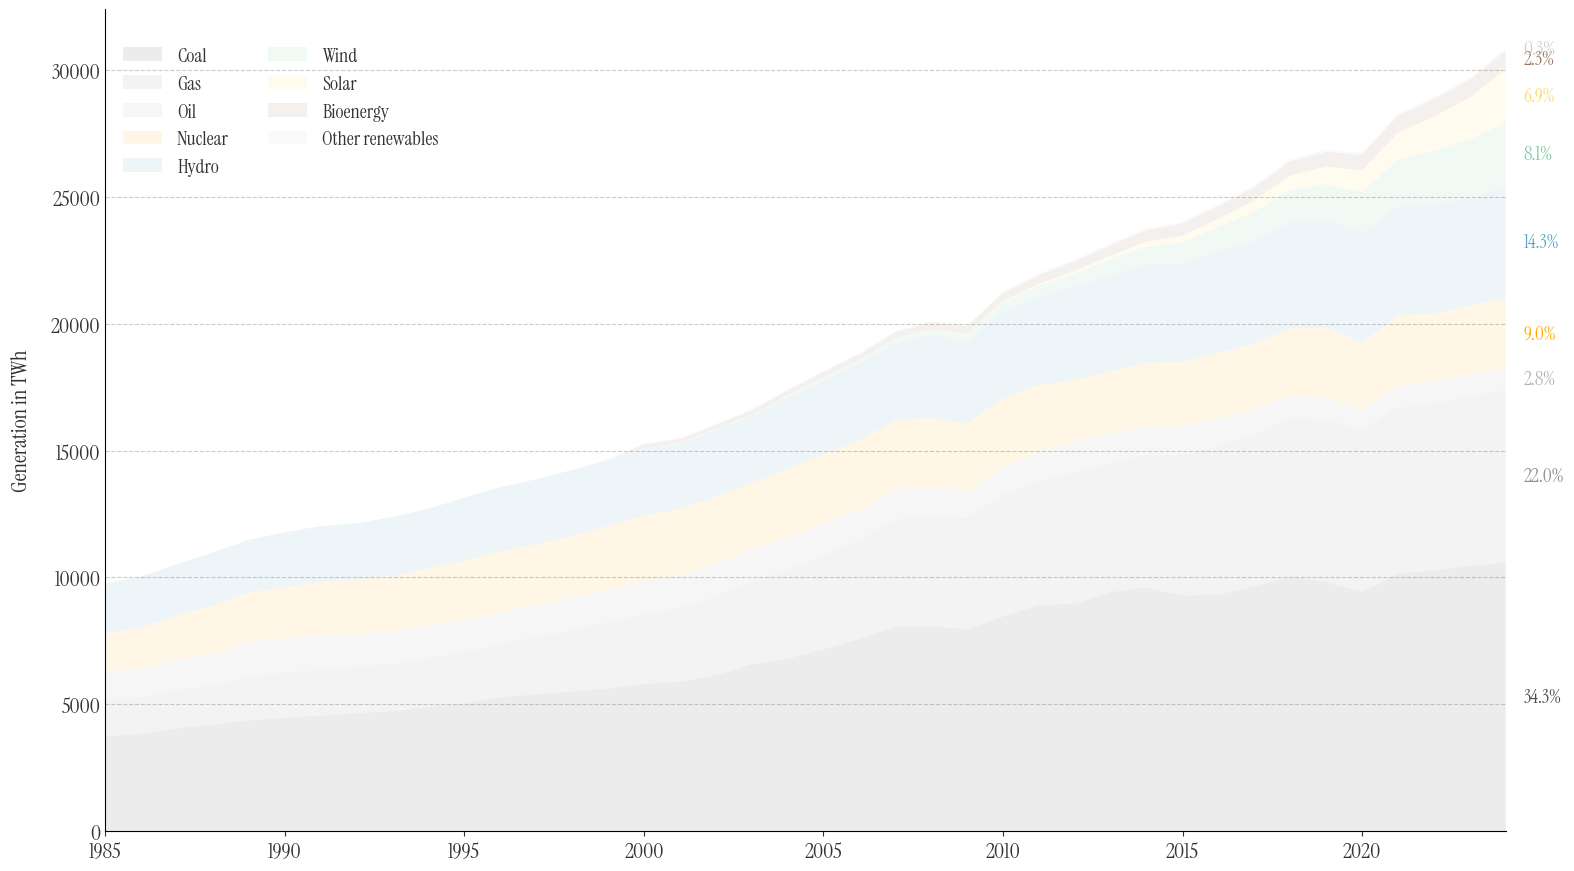

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from dotenv import load_dotenv
import os

# -----------------------------
# 1. Font setup
# -----------------------------
FONT_PATH = "./font.ttf"

fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
FONT_NAME = font_prop.get_name()

# -----------------------------
# 2. Load data
# -----------------------------
df = pd.read_csv("./data/electricity-prod-source-stacked.csv")

df_world = df[df["Entity"] == "World"].copy()

# -----------------------------
# 3. Select & clean source columns
# -----------------------------
SOURCE_COLUMNS = {
    "Electricity from coal - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Coal",
    "Electricity from gas - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Gas",
    "Electricity from oil - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Oil",
    "Electricity from nuclear - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Nuclear",
    "Electricity from hydro - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Hydro",
    "Electricity from wind - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Wind",
    "Electricity from solar - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Solar",
    "Electricity from bioenergy - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Bioenergy",
    "Other renewables excluding bioenergy - TWh (adapted for visualization of chart electricity-prod-source-stacked)": "Other renewables",
}

df_sources = (
    df_world[["Year"] + list(SOURCE_COLUMNS.keys())]
    .rename(columns=SOURCE_COLUMNS)
    .sort_values("Year")
)

# -----------------------------
# 4. Color palette
# -----------------------------

# Load .env file
load_dotenv("colors.env", override=True)

# Access colors
COLORS = {
  "Coal": os.getenv("COAL"),
  "Gas": os.getenv("GAS"),
  "Oil": os.getenv("OIL"),
  "Nuclear": os.getenv("NUCLEAR"),
  "Hydro": os.getenv("HYDRO"),
  "Wind": os.getenv("WIND"),
  "Solar": os.getenv("SOLAR"),
  "Bioenergy": os.getenv("BIOENERGY"),
  "Other renewables": os.getenv("OTHER_RENEWABLES"),
  "black": os.getenv("BLACK"),
  "white": os.getenv("WHITE"),
}


# -----------------------------
# 5. Global style
# -----------------------------
plt.rcParams.update({
    "font.family": FONT_NAME,
    "font.size": 16,

    "text.color": COLORS["black"],
    "axes.labelcolor": COLORS["black"],
    "xtick.color": COLORS["black"],
    "ytick.color": COLORS["black"],

    "figure.facecolor": "none",
    "axes.facecolor": "none",

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.color": COLORS["black"],
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
})

# -----------------------------
# 6. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(df_sources["Year"].min(), df_sources["Year"].max())
ax.stackplot(
    df_sources["Year"],
    [df_sources[col] for col in df_sources.columns[1:]],
    labels=df_sources.columns[1:],
    colors=[COLORS[col] for col in df_sources.columns[1:]],
    alpha=.95
)

# -----------------------------
# 7. labels
# -> no title; looks shit
# -----------------------------

ax.set_ylabel("Generation in TWh", fontsize=16, labelpad=15)

ax.tick_params(axis="both", labelsize=16)
ax.tick_params(axis="y", length=0)

ax.grid(True, axis="y")
ax.set_ylim(bottom=0)

# -----------------------------
# 8. Legend (editorial placement)
# -----------------------------
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0,0.975),
    frameon=False,
    fontsize=14,
    ncol=2,
)

# Get last year values
last_year = df_sources["Year"].iloc[-1]
last_values = df_sources.iloc[-1, 1:]  # skip "Year" column
total = last_values.sum()

# Compute cumulative bottom positions for labels
cumulative = last_values.cumsum() - last_values / 2  # middle of each stack

for i, col in enumerate(df_sources.columns[1:]):
  pct = last_values.iloc[i] / total * 100
  ax.text(
    last_year + 0.5,        # slightly to the right of the last year
    cumulative.iloc[i],          # vertical center of this stack
    f"{pct:.1f}%",          # formatted percentage
    color=COLORS[col],
    fontsize=14,
    va='center',
    alpha=1
  )


# -----------------------------
# 9. Export
# -----------------------------
plt.tight_layout()
plt.savefig(
    "./global_electricity_generation_by_source.svg",
    format="svg",
    bbox_inches="tight",
    transparent=True
)
plt.show()
